## 1. Image Representation

A grayscale image can be treated as a sequence of pixel intensities. If the image has $M \times N$ pixels, then the total number of samples is

$$L = M \times N$$

Each pixel value is represented by an integer in the range $0$ to $255$.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Reading the Image

The image is converted to grayscale so that every pixel is represented by a single intensity value. This gives a 1D sequence

$$p = [p_1, p_2, \dots, p_n]$$

where $n$ is the number of pixels.

In [2]:
# Read grayscale image

image = cv2.imread("cat.png", 0)

## 3. Flattening the Image

The 2D image is flattened into a 1D data stream so that the compression algorithm can process it sequentially.

$$p = \text{flatten}(I)$$

This transformation preserves the order of pixels while simplifying the encoding process.

In [3]:
# Flatten image into 1D array
pixels = image.flatten()

## 4. Frequency of Symbols

Huffman coding first analyzes the frequency of each pixel value. If a symbol $x_i$ appears $f_i$ times, then its probability is

$$P(x_i) = \frac{f_i}{\sum_j f_j}$$

Symbols with higher frequency are assigned shorter codes.

In [4]:
# Step 1: Calculate Frequency

frequency = {}

for pixel in pixels:
    if pixel in frequency:
        frequency[pixel] += 1
    else:
        frequency[pixel] = 1

## 5. Building the Huffman Tree

The Huffman tree is formed by repeatedly merging the two least-frequent nodes. If the frequencies of the two selected nodes are $f_1$ and $f_2$, then the parent node has frequency

$$f_p = f_1 + f_2$$

This process continues until a single root node remains.

In [5]:
# Step 2: Create Huffman Node

class Node:

    def __init__(self, value, freq):
        self.value = value
        self.freq = freq
        self.left = None
        self.right = None

## 6. Tree Construction in Code

This cell implements the manual construction of the Huffman tree. At each iteration, the two nodes with smallest frequency are combined, which is the key idea behind optimal prefix coding.

In [6]:
# Step 3: Build Huffman Tree Manually

nodes = []

for value in frequency:
    nodes.append(Node(value, frequency[value]))

while len(nodes) > 1:

    # Sort nodes by frequency
    nodes.sort(key=lambda x: x.freq)

    left = nodes.pop(0)
    right = nodes.pop(0)

    parent = Node(None, left.freq + right.freq)
    parent.left = left
    parent.right = right

    nodes.append(parent)

root = nodes[0]

## 7. Assigning Codewords

Once the tree is built, each symbol receives a binary code based on its path from the root. If a symbol is reached by a path of length $l$ and bits $b_1b_2\dots b_l$, then its codeword is

$$c = b_1b_2\dots b_l$$

The resulting code is prefix-free, meaning no code is the prefix of another.

In [7]:
# Step 4: Generate Huffman Codes

codes = {}

def generate_code(node, code):

    if node is None:
        return

    if node.value is not None:
        codes[node.value] = code
        return

    generate_code(node.left, code + "0")
    generate_code(node.right, code + "1")

generate_code(root, "")

## 8. Encoding the Data

Each pixel value is replaced by its corresponding Huffman code. The encoded bitstream is therefore

$$E = c_1c_2\dots c_n$$

where each $c_i$ is the code assigned to the $i$-th pixel.

In [8]:
# Step 5: Encode Image

encoded = ""

for pixel in pixels:
    encoded += codes[pixel]

## 9. Decoding the Data

Decoding is performed by traversing the Huffman tree from the root using the bits of the encoded stream. Each time a leaf node is reached, the corresponding symbol is recovered.

This operation reconstructs the original sequence without loss of information.

In [9]:
# Step 6: Decode Image

decoded_pixels = []

current = root

for bit in encoded:

    if bit == '0':
        current = current.left
    else:
        current = current.right

    if current.value is not None:
        decoded_pixels.append(current.value)
        current = root

decoded_image = np.array(decoded_pixels, dtype=np.uint8)
decoded_image = decoded_image.reshape(image.shape)

## 10. Compression Statistics

The compression performance can be measured by comparing the original size with the encoded bitstream length. If the original image uses $8n$ bits and the encoded stream uses $B_{comp}$ bits, then the compression ratio is

$$R = \frac{8n}{B_{comp}}$$

A larger value of $R$ indicates better compression.

In [10]:
# Compression Statistics

original_bits = len(pixels) * 8
compressed_bits = len(encoded)

compression_ratio = original_bits / compressed_bits

print("Original Size (bits):", original_bits)
print("Compressed Size (bits):", compressed_bits)
print("Compression Ratio:", round(compression_ratio,2), ":1")

Original Size (bits): 3092640
Compressed Size (bits): 2917754
Compression Ratio: 1.06 :1


## 11. Visual Comparison

The original and decoded images are displayed side by side to verify that the reconstruction is visually consistent with the source image.

This confirms that Huffman coding is a lossless compression method.

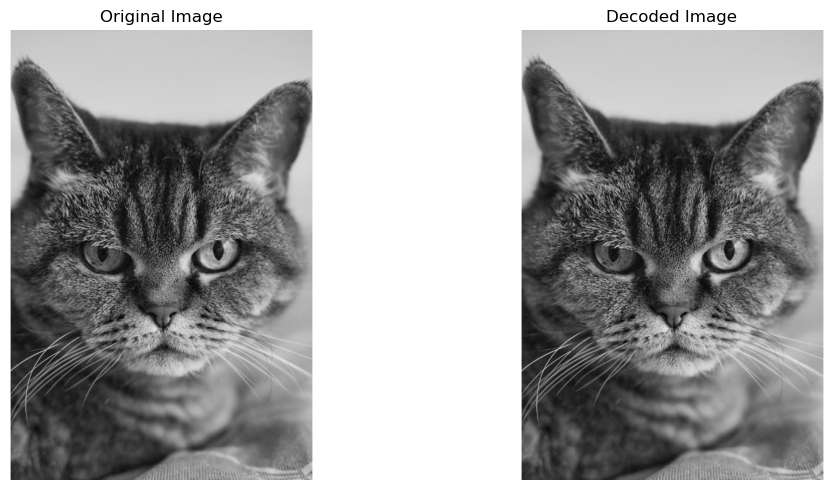

In [11]:
# Display Images

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(decoded_image, cmap='gray')
plt.title("Decoded Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Final Code Table

The final cell prints the binary code assigned to each pixel value. These codewords form the complete dictionary used for compression and decompression.

In [12]:
# Print Huffman Codes

print("\nHuffman Codes")

for key in sorted(codes):
    print(f"{key:3d} : {codes[key]}")


Huffman Codes
  1 : 000101001111100100
  2 : 000101001111100101
  3 : 0001010011111000
  4 : 000101001110101
  5 : 000101001111101
  6 : 00010100111011
  7 : 00010100111001
  8 : 11101111010111
  9 : 1110111101001
 10 : 1110111101010
 11 : 101110101110
 12 : 101110101111
 13 : 10111010110
 14 : 11101111011
 15 : 1011101010
 16 : 1101110111
 17 : 010000000
 18 : 011100101
 19 : 101011111
 20 : 110111010
 21 : 111100000
 22 : 111011100
 23 : 00101000
 24 : 01001011
 25 : 01100111
 26 : 01111110
 27 : 10100100
 28 : 10111001
 29 : 11000011
 30 : 11000111
 31 : 11011001
 32 : 11100010
 33 : 11101011
 34 : 11100110
 35 : 11111000
 36 : 11110100
 37 : 11110111
 38 : 0000011
 39 : 0001011
 40 : 0001111
 41 : 0010011
 42 : 0011101
 43 : 0100001
 44 : 0011110
 45 : 0101010
 46 : 0100100
 47 : 0101111
 48 : 0101101
 49 : 0110101
 50 : 0110110
 51 : 0101110
 52 : 0110100
 53 : 0111011
 54 : 0110111
 55 : 0110010
 56 : 0101100
 57 : 0101011
 58 : 0100111
 59 : 0100110
 60 : 0101001
 61 : 0011011
